# Analyze A/B Test Results

**Student:** Maximus Walker  
**Goal:** Determine whether the e-commerce company should implement the new treatment page, keep the control page, or gather more evidence.

This notebook evaluates the experiment using descriptive statistics, a one-sided two-proportion hypothesis test, and logistic regression with country and treatment-by-country interaction effects.

## Part I - Data and Descriptive Statistics

The dataset contains each participant's country, assigned experiment group, and conversion outcome. The treatment group saw the new page and the control group saw the existing page.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest

# Load the dataset. Keep ab_data.csv in the same folder as this notebook.
df = pd.read_csv('ab_data.csv')
df.head()

,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0


In [2]:
# Basic quality checks
print(f'Rows: {df.shape[0]:,}')
print(f'Duplicate rows: {df.duplicated().sum():,}')
print('Missing values:')
print(df.isna().sum())
print()
print('Group counts:')
print(df['group'].value_counts())
print()
print('Country counts:')
print(df['country'].value_counts())

Rows: 69,889
Duplicate rows: 69,877
Missing values:
country      0
group        0
converted    0
dtype: int64

Group counts:
group
treatment    35211
control      34678
Name: count, dtype: int64

Country counts:
country
US    48850
UK    17551
CA     3488
Name: count, dtype: int64


There are 69,889 observations, with no missing values. Because this version of the project dataset contains only `country`, `group`, and `converted`, identical rows are expected and are not removed: they represent different participants who happen to share the same recorded values.

In [3]:
# Conversion rates by experiment group
group_summary = df.groupby('group')['converted'].agg(participants='count', conversions='sum', conversion_rate='mean')
group_summary

,participants,conversions,conversion_rate
group,,,
control,34678,3650,0.105254
treatment,35211,5469,0.155321


In [4]:
# Conversion rates by country and group
country_rates = df.groupby(['group', 'country'])['converted'].mean().unstack()
country_rates

country,CA,UK,US
group,,,
control,0.094474,0.101649,0.107314
treatment,0.154017,0.148698,0.157769


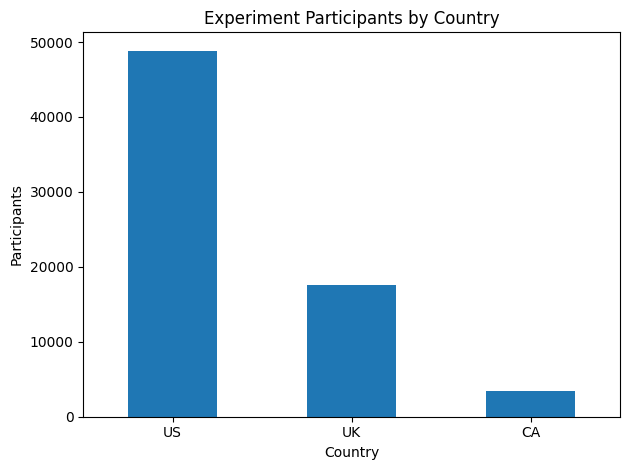

In [5]:
# Participant distribution by country
country_counts = df['country'].value_counts().reindex(['US', 'UK', 'CA'])
ax = country_counts.plot(kind='bar', title='Experiment Participants by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Participants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Descriptive result

- Treatment conversion rate: 15.5321%
- Control conversion rate: 10.5254%
- Observed absolute lift: 5.0067%, or about 5.01 percentage points

The treatment group converted at a higher observed rate. Statistical testing is needed to determine whether this difference is consistent with random variation under the null hypothesis.

## Part II - A/B Test

Let \(p_T\) be the treatment-page conversion probability and \(p_C\) the control-page conversion probability.

- **Null hypothesis:** \(H_0: p_T \le p_C\)
- **Alternative hypothesis:** \(H_1: p_T > p_C\)

A one-sided two-proportion z-test is appropriate because the business question is whether the new page improves conversion.

In [6]:
treatment = df[df['group'] == 'treatment']['converted']
control = df[df['group'] == 'control']['converted']

count = np.array([treatment.sum(), control.sum()])
nobs = np.array([treatment.size, control.size])

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
observed_diff = treatment.mean() - control.mean()

print(f'Treatment conversion rate: {treatment.mean():.6f}')
print(f'Control conversion rate:   {control.mean():.6f}')
print(f'Observed difference:       {observed_diff:.6f}')
print(f'z statistic:               {z_stat:.6f}')
print(f'one-sided p-value:         {p_value:.6e}')

Treatment conversion rate: 0.155321
Control conversion rate:   0.105254
Observed difference:       0.050067
z statistic:               19.647243
one-sided p-value:         3.052007e-86


### Interpretation of the A/B test

The z statistic is 19.647 and the one-sided p-value is 3.052e-86. At a conventional \(a =0.05\) significance level, the p-value is far below the threshold, so the null hypothesis is rejected. The experiment provides very strong statistical evidence that the treatment page has a higher conversion rate than the control page.

The difference is also practically meaningful in this experiment: the estimated lift is about 5.01 percentage points (47.6% relative improvement over the control rate).

## Part III - Regression Approach

Logistic regression models conversion as a binary outcome. The first model includes only treatment assignment. The second adds country indicators, using Canada as the reference country. The third adds treatment-by-country interaction terms to test whether treatment effectiveness changes by country.

In [7]:
model_df = df.copy()
model_df['treatment'] = (model_df['group'] == 'treatment').astype(int)
model_df['UK'] = (model_df['country'] == 'UK').astype(int)
model_df['US'] = (model_df['country'] == 'US').astype(int)

X1 = sm.add_constant(model_df[['treatment']])
logit_treatment = sm.Logit(model_df['converted'], X1).fit()
logit_treatment.summary()

Optimization terminated successfully.
         Current function value: 0.384516
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:                69889
Model:                          Logit   Df Residuals:                    69887
Method:                           MLE   Df Model:                            1
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                0.007175
Time:                        02:11:00   Log-Likelihood:                -26873.
converged:                       True   LL-Null:                       -27068.
Covariance Type:            nonrobust   LLR p-value:                 1.810e-86
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1402      0.017   -122.305      0.000      -2.174      -2.106
treatment      0.4467      0.023     19.539      0.000       0.402       0.492
==============================================================================
"""

The treatment coefficient is positive and statistically significant (two-sided p-value 5.130e-85). Its odds ratio is 1.563, meaning the estimated odds of conversion are about 56.3% higher for treatment than control before adding country.

In [8]:
# Add country main effects. Canada is the reference category.
X2 = sm.add_constant(model_df[['treatment', 'UK', 'US']])
logit_country = sm.Logit(model_df['converted'], X2).fit()
logit_country.summary()

Optimization terminated successfully.
         Current function value: 0.384463
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:                69889
Model:                          Logit   Df Residuals:                    69885
Method:                           MLE   Df Model:                            3
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                0.007312
Time:                        02:11:00   Log-Likelihood:                -26870.
converged:                       True   LL-Null:                       -27068.
Covariance Type:            nonrobust   LLR p-value:                 1.778e-85
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1930      0.053    -41.308      0.000      -2.297      -2.089
treatment      0.4466      0.023     19.534      0.000       0.402       0.491
UK             0.0067      0.056      0.120      0.905      -0.103       0.117
US             0.0727      0.053      1.372      0.170      -0.031       0.177
==============================================================================
"""

### Country main effects

With Canada as the reference country:

- UK p-value: 0.9048
- US p-value: 0.1701
- Treatment p-value: 5.665e-85

Neither country main effect is statistically significant at \(a = 0.05\). The treatment effect remains strongly significant after controlling for country.

In [9]:
# Test whether the treatment effect differs by country.
model_df['treatment_UK'] = model_df['treatment'] * model_df['UK']
model_df['treatment_US'] = model_df['treatment'] * model_df['US']

X3 = sm.add_constant(model_df[['treatment', 'UK', 'US', 'treatment_UK', 'treatment_US']])
logit_interaction = sm.Logit(model_df['converted'], X3).fit()
logit_interaction.summary()

Optimization terminated successfully.
         Current function value: 0.384455
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:                69889
Model:                          Logit   Df Residuals:                    69883
Method:                           MLE   Df Model:                            5
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                0.007333
Time:                        02:11:00   Log-Likelihood:                -26869.
converged:                       True   LL-Null:                       -27068.
Covariance Type:            nonrobust   LLR p-value:                 1.315e-83
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.2602      0.083    -27.120      0.000      -2.424      -2.097
treatment        0.5568      0.106      5.261      0.000       0.349       0.764
UK               0.0812      0.091      0.897      0.370      -0.096       0.259
US               0.1417      0.086      1.650      0.099      -0.027       0.310
treatment_UK    -0.1226      0.116     -1.061      0.289      -0.349       0.104
treatment_US    -0.1132      0.109     -1.036      0.300      -0.327       0.101
================================================================================
"""

### Interaction effects

The interaction terms directly test whether the treatment effect changes by country relative to Canada.

- Treatment × UK p-value: 0.2887
- Treatment × US p-value: 0.3001

Both interaction p-values are greater than 0.05, so there is no statistically significant evidence that the treatment effect differs between Canada, the UK, and the US. In other words, country does not appear to meaningfully modify the page's treatment effect in this experiment.

In [10]:
# Compare model fit with Akaike Information Criterion (lower is preferred).
model_fit = pd.DataFrame({
    'Model': ['Treatment only', 'Treatment + country', 'Treatment + country + interactions'],
    'AIC': [logit_treatment.aic, logit_country.aic, logit_interaction.aic],
    'Pseudo R-squared': [logit_treatment.prsquared, logit_country.prsquared, logit_interaction.prsquared]
})
model_fit

,Model,AIC,Pseudo R-squared
0,Treatment only,53750.878850,0.007175
1,Treatment + country,53747.494876,0.007312
2,Treatment + country + interactions,53750.318895,0.007333


The main-effects model has the lowest AIC (**53747.49**), while adding interactions increases AIC to 53750.32. This supports the interpretation that treatment is important, while the country-specific interaction terms do not add useful explanatory value.

## Final Recommendation

The new treatment page should be implemented based on the evidence in this experiment. The treatment conversion rate is approximately 15.53% versus 10.53% for control, a gain of about 5.01 percentage points. The one-sided two-proportion test finds an extremely small p-value, and logistic regression confirms a strong treatment association with conversion.

Country is not a statistically significant predictor after treatment is included, and the treatment-by-country interaction terms are also not statistically significant. Therefore, the observed treatment advantage appears broadly consistent across the three countries in the dataset.

### Practical caveats

This conclusion is about conversion performance during the observed experiment. Before a full rollout, the company should still consider the implementation cost, revenue per conversion, experiment duration, seasonality, and whether the sample is representative of future traffic. Statistical significance alone would not guarantee positive long-term business value.